# Empirical consistency of single-linkage clustering (ARI) as N,n grow

This notebook reuses the data-generation + OM distance code from `om_convergence.ipynb`,
then checks empirically that **single-linkage** recovers the true latent clusters as both:
- the number of sequences **N** grows
- the sequence length **n** grows

We report **Adjusted Rand Index (ARI)** across repetitions.


In [1]:
# --- Reused utilities from om_convergence.ipynb (cells 0,1,2,7) ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from contextlib import contextmanager
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt


try:
    from numba import njit, prange
except Exception:
    print("Warning: numba not available, falling back to pure Python.")

    def njit(*args, **kwargs):
        def deco(fn):
            return fn
        return deco

    def prange(x):
        return range(x)


c:\Users\Ottavio KHALIFA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _expand_dirichlet_alpha(alpha, n_rows, n_cols, name="alpha"):
    if np.isscalar(alpha):
        if alpha <= 0:
            raise ValueError(f"{name} must be > 0")
        return np.full((n_rows, n_cols), float(alpha))
    arr = np.asarray(alpha, dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] != n_cols:
            raise ValueError(f"{name} must have length {n_cols}")
        if np.any(arr <= 0):
            raise ValueError(f"All values of {name} must be > 0")
        return np.tile(arr, (n_rows, 1))
    if arr.ndim == 2:
        if arr.shape != (n_rows, n_cols):
            raise ValueError(f"{name} must have shape ({n_rows}, {n_cols})")
        if np.any(arr <= 0):
            raise ValueError(f"All values of {name} must be > 0")
        return arr
    raise ValueError(f"{name} must be a scalar, 1D, or 2D array")


def _expand_dirichlet_alpha_context(alpha, n_contexts, name="alpha_init"):
    if np.isscalar(alpha):
        if alpha <= 0:
            raise ValueError(f"{name} must be > 0")
        return np.full(n_contexts, float(alpha))
    arr = np.asarray(alpha, dtype=float).reshape(-1)
    if arr.shape[0] != n_contexts:
        raise ValueError(f"{name} must have length {n_contexts}")
    if np.any(arr <= 0):
        raise ValueError(f"All values of {name} must be > 0")
    return arr


def _context_to_index(context, n_states):
    idx = 0
    for s in context:
        idx = idx * n_states + int(s)
    return idx


def _index_to_context(idx, n_states, order):
    context = [0] * order
    for pos in range(order - 1, -1, -1):
        context[pos] = int(idx % n_states)
        idx //= n_states
    return context


def sample_markov_model(n_states, order_k, alpha, rng, alpha_init=None):
    if order_k < 1:
        raise ValueError("order_k must be >= 1")
    if n_states < 2:
        raise ValueError("n_states must be >= 2")
    n_contexts = n_states ** order_k
    trans_alpha = _expand_dirichlet_alpha(alpha, n_contexts, n_states, name="alpha")
    transitions = np.empty((n_contexts, n_states), dtype=float)
    for i in range(n_contexts):
        transitions[i] = rng.dirichlet(trans_alpha[i])
    if alpha_init is None:
        alpha_init = alpha
    if order_k == 1:
        init_alpha = _expand_dirichlet_alpha(alpha_init, 1, n_states, name="alpha_init")[0]
        init_probs = rng.dirichlet(init_alpha)
    else:
        init_alpha = _expand_dirichlet_alpha_context(alpha_init, n_contexts, name="alpha_init")
        init_probs = rng.dirichlet(init_alpha)
    return {
        "n_states": n_states,
        "order": order_k,
        "transitions": transitions,
        "init_probs": init_probs,
    }


def sample_two_markov_models(
    n_states,
    order_k,
    alpha,
    seed=None,
    rng=None,
    alpha_init=None,
    same_model=False,
):
    if rng is None:
        rng = np.random.default_rng(seed)
    model_a = sample_markov_model(n_states, order_k, alpha, rng, alpha_init=alpha_init)
    if same_model:
        model_b = {
            "n_states": model_a["n_states"],
            "order": model_a["order"],
            "transitions": np.array(model_a["transitions"], copy=True),
            "init_probs": np.array(model_a["init_probs"], copy=True),
        }
    else:
        model_b = sample_markov_model(n_states, order_k, alpha, rng, alpha_init=alpha_init)
    return model_a, model_b


def _sample_initial_context(model, rng):
    order = model["order"]
    n_states = model["n_states"]
    p = model["init_probs"]
    if order == 1:
        state = int(rng.choice(n_states, p=p))
        return [state]
    idx = int(rng.choice(p.size, p=p))
    return _index_to_context(idx, n_states, order)


def _sample_next_state(model, context, rng):
    idx = _context_to_index(context, model["n_states"])
    probs = model["transitions"][idx]
    return int(rng.choice(model["n_states"], p=probs))


def generate_incremental_pairs(model_x, model_y, n, rng):
    if n <= 0:
        raise ValueError("n must be > 0")
    if model_x["order"] != model_y["order"]:
        raise ValueError("Both models must have the same order_k")
    if model_x["n_states"] != model_y["n_states"]:
        raise ValueError("Both models must have the same n_states")
    order = model_x["order"]
    x_seq = _sample_initial_context(model_x, rng)
    y_seq = _sample_initial_context(model_y, rng)
    pairs = []
    max_init = min(n, order)
    for k in range(1, max_init + 1):
        pairs.append(
            (np.array(x_seq[:k], dtype=np.int64), np.array(y_seq[:k], dtype=np.int64))
        )
    if n <= order:
        return pairs
    x_context = x_seq[-order:]
    y_context = y_seq[-order:]
    for t in range(order, n):
        x_next = _sample_next_state(model_x, x_context, rng)
        y_next = _sample_next_state(model_y, y_context, rng)
        x_seq.append(x_next)
        y_seq.append(y_next)
        x_context = x_seq[-order:]
        y_context = y_seq[-order:]
        pairs.append(
            (np.array(x_seq[: t + 1], dtype=np.int64), np.array(y_seq[: t + 1], dtype=np.int64))
        )
    return pairs


In [4]:
# Adapted from CTSTransformer/codex/BENCHARNUMBA/om_distance.py

def compute_trate_subst_matrix(sequences, n_states=None, pad_value=None, smoothing=1e-8):
    if n_states is None:
        max_val = 0
        for seq in sequences:
            if len(seq) > 0:
                max_val = max(max_val, int(np.max(seq)))
        n_states = max_val + 1
    counts = np.zeros((n_states, n_states), dtype=float)
    for seq in sequences:
        arr = np.asarray(seq, dtype=np.int64).reshape(-1)
        if pad_value is not None:
            arr = arr[arr != pad_value]
        if arr.size >= 2:
            p = arr[:-1]
            n = arr[1:]
            idx = p * n_states + n
            counts += np.bincount(idx, minlength=n_states * n_states).reshape(n_states, n_states)
    row_sums = counts.sum(axis=1, keepdims=True)
    P = (counts + smoothing) / (row_sums + smoothing * n_states)
    S = 2.0 - P - P.T
    np.fill_diagonal(S, 0.0)
    return S


def compute_constant_subst_matrix(n_states, cost=1.0):
    if n_states is None or n_states < 2:
        raise ValueError("n_states must be >= 2")
    S = np.full((n_states, n_states), float(cost))
    np.fill_diagonal(S, 0.0)
    return S


def compute_random_subst_matrix(n_states, rng, low=0.5, high=2.0):
    if n_states is None or n_states < 2:
        raise ValueError("n_states must be >= 2")
    if low <= 0 or high <= 0 or high <= low:
        raise ValueError("low and high must be > 0 with high > low")
    M = rng.uniform(low, high, size=(n_states, n_states))
    S = 0.5 * (M + M.T)
    np.fill_diagonal(S, 0.0)
    return S


def choose_indel_cost(subst_cost, strategy="median_nonzero"):
    C = subst_cost.shape[0]
    offdiag = subst_cost[~np.eye(C, dtype=bool)]
    offdiag = offdiag[offdiag > 0]
    if offdiag.size == 0:
        return 1.0
    if strategy == "mean_nonzero":
        return float(offdiag.mean())
    return float(np.median(offdiag))


@njit(fastmath=True)
def _om_distance_univariate_numba(A, B, subst_cost, indel_cost):
    n = A.shape[0]
    m = B.shape[0]
    dp = np.empty((n + 1, m + 1), dtype=np.float64)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        dp[i, 0] = dp[i - 1, 0] + indel_cost
    for j in range(1, m + 1):
        dp[0, j] = dp[0, j - 1] + indel_cost
    for i in range(1, n + 1):
        ai = A[i - 1]
        for j in range(1, m + 1):
            bj = B[j - 1]
            d_del = dp[i - 1, j] + indel_cost
            d_ins = dp[i, j - 1] + indel_cost
            d_sub = dp[i - 1, j - 1] + subst_cost[ai, bj]
            best = d_del if d_del < d_ins else d_ins
            if d_sub < best:
                best = d_sub
            dp[i, j] = best
    return dp[n, m]


@njit(fastmath=True, parallel=True)
def om_distances_pairs_numba(X_pad, X_len, Y_pad, Y_len, subst_cost, indel_cost, normalize_by_length):
    N = X_pad.shape[0]
    out = np.zeros(N, dtype=np.float64)
    for i in prange(N):
        Li = X_len[i]
        Lj = Y_len[i]
        A = X_pad[i, :Li]
        B = Y_pad[i, :Lj]
        d = _om_distance_univariate_numba(A, B, subst_cost, indel_cost)
        if normalize_by_length:
            L = Li if Li >= Lj else Lj
            if L > 0:
                d = d / L
        out[i] = d
    return out


def _pad_sequences(sequences, pad_value=-1):
    lengths = np.array([len(s) for s in sequences], dtype=np.int64)
    if lengths.size == 0:
        raise ValueError("No sequences provided")
    Lmax = int(lengths.max())
    X = np.full((len(sequences), Lmax), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        X[i, :len(seq)] = seq
    return X, lengths


def compute_om_distances_parallel(X_list, Y_list, subst_cost, indel_cost, normalize_by_length=True):
    if len(X_list) != len(Y_list):
        raise ValueError("X_list and Y_list must have the same length")
    X_pad, X_len = _pad_sequences(X_list)
    Y_pad, Y_len = _pad_sequences(Y_list)
    return om_distances_pairs_numba(
        X_pad, X_len, Y_pad, Y_len, subst_cost, float(indel_cost), normalize_by_length
    )


In [5]:

def simulate_markov_sequence(model, n, rng):
    """
    Utilise _sample_initial_context et _sample_next_state du notebook.
    """
    order = model["order"]
    context = list(_sample_initial_context(model, rng))
    seq = list(context)
    while len(seq) < n:
        x_next = _sample_next_state(model, seq[-order:], rng)
        seq.append(int(x_next))
    return np.asarray(seq[:n], dtype=np.int64)


def estimate_gamma_by_prefix_convergence(
    model_a,
    model_b,
    subst_cost,
    indel_cost,
    n_max=2000,
    check_every=100,
    window=5,
    delta=1e-3,
    seed_a=0,
    seed_b=1,
):
    """
    Estime gamma(model_a, model_b) via D_n/n qui se stabilise.
    """
    rng_a = np.random.default_rng(seed_a)
    rng_b = np.random.default_rng(seed_b)

    x = simulate_markov_sequence(model_a, n_max, rng_a)
    y = simulate_markov_sequence(model_b, n_max, rng_b)

    n_vals, D_vals, D_over_n = [], [], []

    for n in range(check_every, n_max + 1, check_every):
        Dn = _om_distance_univariate_numba(x[:n], y[:n], subst_cost, float(indel_cost))
        n_vals.append(n)
        D_vals.append(float(Dn))
        D_over_n.append(float(Dn) / float(n))

        if len(D_over_n) >= window:
            recent = D_over_n[-window:]
            if (max(recent) - min(recent)) <= delta:
                break

    return D_over_n[-1], {
        "n_vals": np.asarray(n_vals, dtype=int),
        "D_vals": np.asarray(D_vals, dtype=float),
        "D_over_n": np.asarray(D_over_n, dtype=float),
        "stopped_early": (n_vals[-1] < n_max),
    }


In [6]:
def make_mixture_dataset(
    K: int,
    N: int,
    n: int,
    n_states: int,
    order_k: int,
    alpha: float,
    weights=None,
    seed: int = 0,
):
    """Sample K Markov models, then N sequences with latent labels Z ~ Categorical(weights)."""
    rng = np.random.default_rng(seed)
    if weights is None:
        weights = np.full(K, 1.0 / K)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    models = [sample_markov_model(n_states, order_k, alpha, rng=rng) for _ in range(K)]
    labels = rng.choice(np.arange(K), size=N, p=weights)
    sequences = [simulate_markov_sequence(models[int(z)], n, rng) for z in labels]
    return sequences, labels, models

def pairwise_distance_matrix_om(sequences, subst_cost, indel_cost, normalize_by_length=True):
    """Full NxN symmetric distance matrix using compute_om_distances_parallel."""
    N = len(sequences)
    D = np.zeros((N, N), dtype=np.float64)
    X_list, Y_list, pairs = [], [], []
    for i in range(N):
        for j in range(i+1, N):
            X_list.append(sequences[i])
            Y_list.append(sequences[j])
            pairs.append((i, j))
    if pairs:
        dists = compute_om_distances_parallel(
            X_list, Y_list,
            subst_cost=subst_cost,
            indel_cost=float(indel_cost),
            normalize_by_length=normalize_by_length,
        )
        for (i, j), d in zip(pairs, dists):
            D[i, j] = D[j, i] = float(d)
    return D


In [7]:


def single_linkage_ari_from_distance(D, true_labels, K):
    """Single-linkage clustering on precomputed distances, returns ARI."""
    try:
        model = AgglomerativeClustering(n_clusters=K, linkage='single', metric='precomputed')
    except TypeError:
        model = AgglomerativeClustering(n_clusters=K, linkage='single', affinity='precomputed')
    pred = model.fit_predict(D)
    return float(adjusted_rand_score(true_labels, pred))


In [8]:
import pandas as pd

def sweep_ari_single_linkage(
    Ns,
    ns,
    K=3,
    n_states=8,
    order_k=1,
    alpha=0.7,
    weights=None,
    subst_method='constant',
    constant_cost=1.0,
    indel_strategy='median_nonzero',
    reps=5,
    base_seed=0,
):
    rows = []
    for N in Ns:
        for n in ns:
            for r in range(reps):
                seed = int(base_seed + 100000*N + 100*n + r)
                seqs, labels, models = make_mixture_dataset(
                    K=K, N=N, n=n,
                    n_states=n_states, order_k=order_k, alpha=alpha,
                    weights=weights, seed=seed
                )

                # substitution + indel costs
                if subst_method == 'trate':
                    # pooled stationary symbol distribution proxy
                    pis = []
                    for m in models:
                        P = build_context_transition_matrix(m)
                        pis.append(stationary_symbol_distribution(P, m['n_states'], m['order']))
                    pi_bar = np.mean(np.stack(pis, axis=0), axis=0)
                    subst = compute_trate_subst_matrix(pi_bar, smoothing=1e-8)
                elif subst_method == 'constant':
                    subst = compute_constant_subst_matrix(n_states, cost=constant_cost)
                else:
                    subst = compute_random_subst_matrix(n_states, low=0.5, high=2.0, rng=np.random.default_rng(seed))

                indel = choose_indel_cost(subst, strategy=indel_strategy)
                D = pairwise_distance_matrix_om(seqs, subst_cost=subst, indel_cost=indel, normalize_by_length=True)
                ari = single_linkage_ari_from_distance(D, labels, K=K)
                rows.append({'N': N, 'n': n, 'rep': r, 'ari': ari})
    return pd.DataFrame(rows)


In [ ]:
# --- Run a moderate sweep (edit grids if you want heavier runs) ---
Ns = [30, 60, 90, 120]
ns = [100, 200, 400, 800]

df = sweep_ari_single_linkage(
    Ns=Ns,
    ns=ns,
    K=5,
    n_states=10,
    order_k=1,
    alpha=0.7,
    weights=[0.2, 0.3, 0.1, 0.2, 0.2],
    subst_method='constant',
    constant_cost=1.0,
    reps=3,
    base_seed=123,
)

df.head(), df.shape


(    N    n  rep       ari
 0  30  100    0  0.389553
 1  30  100    1  0.132950
 2  30  100    2  0.090965
 3  30  200    0  1.000000
 4  30  200    1  0.669073,
 (48, 4))

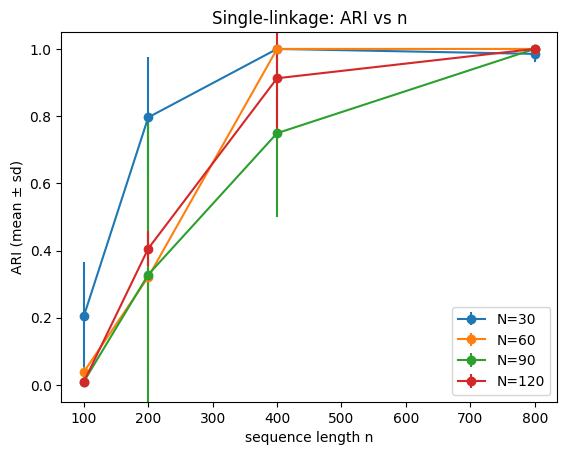

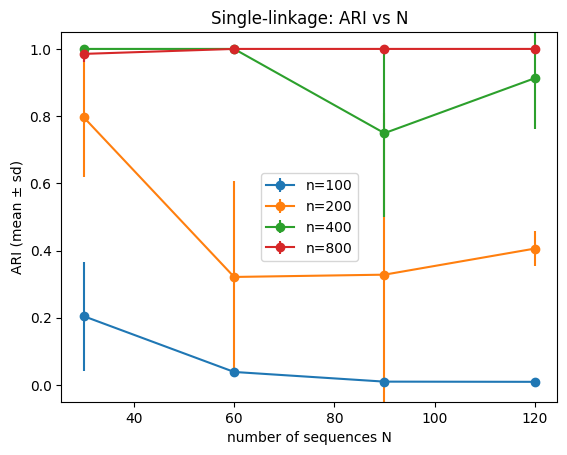

In [16]:

def plot_ari_vs_n(df):
    plt.figure()
    for N in sorted(df['N'].unique()):
        sub = df[df['N']==N].groupby('n')['ari'].agg(['mean','std']).reset_index()
        plt.errorbar(sub['n'], sub['mean'], yerr=sub['std'], marker='o', label=f'N={N}')
    plt.ylim(-0.05, 1.05)
    plt.xlabel('sequence length n')
    plt.ylabel('ARI (mean Â± sd)')
    plt.title('Single-linkage: ARI vs n')
    plt.legend()
    plt.show()

def plot_ari_vs_N(df):
    plt.figure()
    for n in sorted(df['n'].unique()):
        sub = df[df['n']==n].groupby('N')['ari'].agg(['mean','std']).reset_index()
        plt.errorbar(sub['N'], sub['mean'], yerr=sub['std'], marker='o', label=f'n={n}')
    plt.ylim(-0.05, 1.05)
    plt.xlabel('number of sequences N')
    plt.ylabel('ARI (mean Â± sd)')
    plt.title('Single-linkage: ARI vs N')
    plt.legend()
    plt.show()

plot_ari_vs_n(df)
plot_ari_vs_N(df)


In [9]:
# --- K-medoids (PAM) on precomputed distances ---
def _k_medoids_pam(D, K, n_init=5, max_iter=100, seed=0):
    D = np.asarray(D, dtype=float)
    N = D.shape[0]
    if K > N:
        raise ValueError("K must be <= number of points")
    rng = np.random.default_rng(seed)
    best_labels = None
    best_medoids = None
    best_cost = np.inf

    for _ in range(n_init):
        medoids = rng.choice(N, size=K, replace=False)

        for _ in range(max_iter):
            labels = np.argmin(D[:, medoids], axis=1)

            new_medoids = medoids.copy()
            for k in range(K):
                idx = np.where(labels == k)[0]
                if len(idx) == 0:
                    # re-seed empty cluster
                    candidates = np.setdiff1d(np.arange(N), new_medoids, assume_unique=False)
                    if len(candidates) == 0:
                        new_medoids[k] = rng.integers(0, N)
                    else:
                        new_medoids[k] = rng.choice(candidates)
                    continue
                sub = D[np.ix_(idx, idx)]
                new_medoids[k] = idx[np.argmin(sub.sum(axis=1))]
            if np.array_equal(new_medoids, medoids):
                break
            medoids = new_medoids

        labels = np.argmin(D[:, medoids], axis=1)
        cost = D[np.arange(N), medoids[labels]].sum()
        if cost < best_cost:
            best_cost = cost
            best_labels = labels.copy()
            best_medoids = medoids.copy()

    return best_labels, best_medoids, best_cost


def k_medoids_ari_from_distance(D, true_labels, K, n_init=5, max_iter=100, seed=0):
    labels, _, _ = _k_medoids_pam(D, K=K, n_init=n_init, max_iter=max_iter, seed=seed)
    return float(adjusted_rand_score(true_labels, labels))


In [10]:
import pandas as pd

def sweep_ari_k_medoids(
    Ns,
    ns,
    K=3,
    n_states=8,
    order_k=1,
    alpha=0.7,
    weights=None,
    subst_method='constant',
    constant_cost=1.0,
    indel_strategy='median_nonzero',
    reps=5,
    base_seed=0,
    n_init=5,
    max_iter=100,
):
    rows = []
    for N in Ns:
        for n in ns:
            for r in range(reps):
                seed = int(base_seed + 100000*N + 100*n + r)
                seqs, labels, models = make_mixture_dataset(
                    K=K, N=N, n=n,
                    n_states=n_states, order_k=order_k, alpha=alpha,
                    weights=weights, seed=seed
                )

                # substitution + indel costs
                if subst_method == 'trate':
                    # pooled stationary symbol distribution proxy
                    pis = []
                    for m in models:
                        P = build_context_transition_matrix(m)
                        pis.append(stationary_symbol_distribution(P, m['n_states'], m['order']))
                    pi_bar = np.mean(np.stack(pis, axis=0), axis=0)
                    subst = compute_trate_subst_matrix(pi_bar, smoothing=1e-8)
                elif subst_method == 'constant':
                    subst = compute_constant_subst_matrix(n_states, cost=constant_cost)
                else:
                    subst = compute_random_subst_matrix(n_states, low=0.5, high=2.0, rng=np.random.default_rng(seed))

                indel = choose_indel_cost(subst, strategy=indel_strategy)
                D = pairwise_distance_matrix_om(seqs, subst_cost=subst, indel_cost=indel, normalize_by_length=True)
                ari = k_medoids_ari_from_distance(D, labels, K=K, n_init=n_init, max_iter=max_iter, seed=seed)
                rows.append({'N': N, 'n': n, 'rep': r, 'ari': ari})
    return pd.DataFrame(rows)


In [ ]:
# --- Run a moderate sweep (edit grids if you want heavier runs) ---
Ns = [30, 100, 200, 500, 1000]
ns = [100, 200, 400, 800, 1000]

df_kmedoids = sweep_ari_k_medoids(
    Ns=Ns,
    ns=ns,
    K=5,
    n_states=10,
    order_k=1,
    alpha=0.7,
    weights=[0.2, 0.3, 0.1, 0.2, 0.2],
    subst_method='constant',
    constant_cost=1.0,
    reps=3,
    base_seed=123,
    n_init=5,
    max_iter=100,
)

df_kmedoids.head(), df_kmedoids.shape


In [ ]:
def plot_ari_vs_n_kmedoids(df):
    plt.figure()
    for N in sorted(df['N'].unique()):
        sub = df[df['N']==N].groupby('n')['ari'].agg(['mean','std']).reset_index()
        plt.errorbar(sub['n'], sub['mean'], yerr=sub['std'], marker='o', label=f'N={N}')
    plt.ylim(-0.05, 1.05)
    plt.xlabel('sequence length n')
    plt.ylabel('ARI (mean +/- sd)')
    plt.title('K-medoids: ARI vs n')
    plt.legend()
    plt.show()

def plot_ari_vs_N_kmedoids(df):
    plt.figure()
    for n in sorted(df['n'].unique()):
        sub = df[df['n']==n].groupby('N')['ari'].agg(['mean','std']).reset_index()
        plt.errorbar(sub['N'], sub['mean'], yerr=sub['std'], marker='o', label=f'n={n}')
    plt.ylim(-0.05, 1.05)
    plt.xlabel('number of sequences N')
    plt.ylabel('ARI (mean +/- sd)')
    plt.title('K-medoids: ARI vs N')
    plt.legend()
    plt.show()

plot_ari_vs_n_kmedoids(df_kmedoids)
plot_ari_vs_N_kmedoids(df_kmedoids)
